<a href="https://colab.research.google.com/github/jabri62018/Zx_RieOS_v1.1/blob/Zx_RieOS_v1.1/Zx_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 X       gam       cal kn  const_val                meaning       dif                    z                    z'                  z''                  z'''
 1 1.413e+01 3.226e+01 pi  3.142e+00 النسبة الثابتة للدائرة 1.012e+00 4.494e-01-1.245e+00j -5.417e-01-3.186e-02j 2.076e-01+1.657e+00j  4.949e+00-3.973e+00j
 2 2.102e+01 1.216e+02 pi  3.142e+00 النسبة الثابتة للدائرة 1.588e+00 3.059e-01-9.125e-01j -5.466e-01-4.076e-02j 4.690e-01+2.400e+00j  7.145e+00-9.193e+00j
 3 2.501e+01 2.113e+02 pi  3.142e+00 النسبة الثابتة للدائرة 1.828e+00 2.588e-01-7.946e-01j -5.498e-01-4.570e-02j 6.517e-01+2.793e+00j  7.837e+00-1.253e+01j
 4 3.042e+01 3.884e+02 pi  3.142e+00 النسبة الثابتة للدائرة 2.092e+00 2.145e-01-6.789e-01j -5.544e-01-5.196e-02j 9.221e-01+3.285e+00j  8.245e+00-1.711e+01j
 5 3.294e+01 4.953e+02 pi  3.142e+00 النسبة الثابتة للدائرة 2.198e+00 1.989e-01-6.367e-01j -5.565e-01-5.467e-02j 1.053e+00+3.497e+00j  8.270e+00-1.922e+01j
 6 3.759e+01 7.406e+02 pi  3.142e+00 النسبة الثابتة للدائرة 2.37

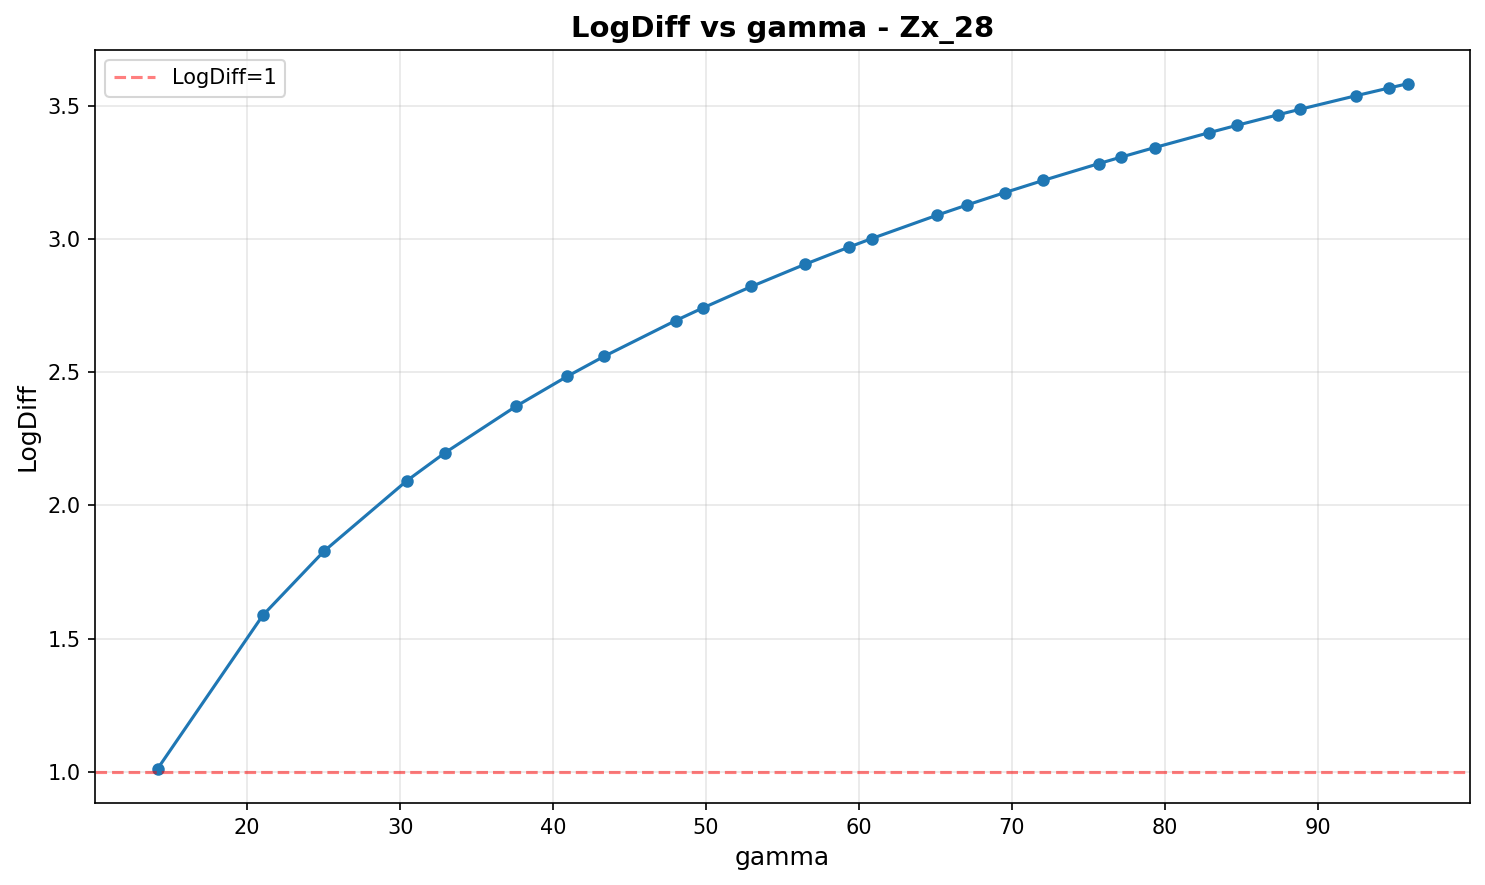

In [ ]:

#file= Zx_28.ipynb
#Author= Abdull Al-Jabri
#م/عبدالله الجبري (صنعاء-اليمن)
#jabri62018@gmail.com

CONSTANTS = {
    'pi': {'val': np.pi, 'meaning': 'النسبة الثابتة للدائرة'},
    'e': {'val': np.e, 'meaning': 'أساس اللوغاريتم الطبيعي'},
    'c': {'val': 299792458.0, 'meaning': 'سرعة الضوء بالمتر/ثانية'}
}

rows = []
for i, gamma in enumerate(gammas):
    C_val, z_m, dz_m, d2z_m, d3z_m = compute_C_and_derivs(gamma, t)

    if np.isfinite(C_val):
        logC = np.log10(abs(C_val) + 1e-300)

        # نجيب أقرب ثابت وقيمته
        kn, dif = min(
            ((k, abs(logC - np.log10(abs(v['val'])+1e-300)))
             for k,v in CONSTANTS.items()),
            key=lambda x: x[1]
        )
        const_val = CONSTANTS[kn]['val']
        meaning = CONSTANTS[kn]['meaning']
    else:
        kn, dif, const_val, meaning = 'nan', np.nan, np.nan, 'nan'

    rows.append([i+1, gamma, C_val, kn, const_val, meaning, dif, z_m, dz_m, d2z_m, d3z_m])

# 28 سطر بالضبط
df = pd.DataFrame(rows, columns=[
    'X','gam','cal','kn','const_val','meaning','dif','z',"z'","z''","z'''"
])

pd.set_option('display.float_format', '{:.3e}'.format)
print(df.to_string(index=False))
df.to_csv("Zx_28_correct.csv", index=False, float_format='%.3e')
print(f"\n✓ تم: 28 سطر محفوظين في Zx_28_correct.csv")

%matplotlib inline
import matplotlib.pyplot as plt

plot_df = df[np.isfinite(df['dif'])].copy()

plt.figure(figsize=(10, 6))
plt.plot(plot_df['gam'], plot_df['dif'], 'o-', markersize=5, linewidth=1.5)
plt.xlabel('gamma', fontsize=12)
plt.ylabel('LogDiff', fontsize=12)
plt.title('LogDiff vs gamma - Zx_28', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='LogDiff=1')
plt.legend()
plt.tight_layout()
plt.show()